In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from scipy.stats import pearsonr
from plots import *

In [ ]:
pred = torch.load("../figure2/pred_26628910_26825518_kidzoi.pt")
targ = torch.load("../figure2/targ_26628910_26825518_kidzoi.pt")

cell_names = {"0": 'Immune',
           '1': 'STR',
           '2': 'Pod',
           '3': 'CD',
           '4': 'CFH',
           '5':'Tcell',
           '6':'END',
           '7': 'DT',
           '8': 'PT',
           '9': 'LOH'
          }

In [3]:
plots_dir='./'

In [2]:
def get_gene_annotations(interval, genome='hg38', gene_filter=None):
    """
    Fetch gene annotations for a given interval.
    
    Parameters:
    -----------
    interval : object with .chrom, .start, .end
    genome : str
        Genome version
    gene_filter : str or list of str, optional
        Gene name(s) to filter for. If provided, only these genes are returned.
    """
    try:
        from pyensembl import EnsemblRelease
        ensembl = EnsemblRelease(release=110, species='human')
        
        # Extract chromosome name (remove 'chr' prefix if present)
        chrom = interval.chrom.replace('chr', '')
        
        # Get all genes that overlap this interval
        genes = ensembl.genes_at_locus(
            contig=chrom,
            position=interval.start,
            end=interval.end
        )
        
        # Filter genes if requested
        if gene_filter:
            if isinstance(gene_filter, str):
                gene_filter = [gene_filter]
            genes = [g for g in genes if g.gene_name in gene_filter]
        
        return genes
        
    except Exception as e:
        print(f"Error fetching genes: {e}")
        return []

def plot_gene_track(ax, interval, genes):
    """
    Plot gene structure similar to IGV with improved styling.
    """
    if not genes:
        ax.text(0.5, 0.5, 'No genes found', 
                transform=ax.transAxes, ha='center', va='center',
                fontsize=6, color='gray')
        ax.set_ylim(0, 1)
        ax.set_xlim(interval.start, interval.end)
        ax.set_yticks([])
        ax.set_ylabel('Genes', fontsize=6)
        sns.despine(ax=ax, left=True, top=True, right=True, bottom=True)
        return
    
    # Adjust spacing based on number of genes
    n_genes = len(genes)
    spacing = 0.5
    ax.set_ylim(-n_genes * spacing + 0.2, 0.8)
    ax.set_xlim(interval.start, interval.end)
    
    for i, gene in enumerate(genes):
        y_pos = -i * spacing
        
        # Draw gene body (thin line connecting exons)
        ax.plot([gene.start, gene.end], [y_pos, y_pos], 
                color='gray', linewidth=0.8, zorder=1, alpha=0.7)
        
        # Draw exons (thick blue rectangles)
        try:
            exons_plotted = False
            for exon in gene.exons:
                # Only plot exons that overlap with the visible interval
                if exon.end >= interval.start and exon.start <= interval.end:
                    exon_start = max(exon.start, interval.start)
                    exon_end = min(exon.end, interval.end)
                    
                    rect = mpatches.Rectangle(
                        (exon_start, y_pos - 0.12),
                        exon_end - exon_start,
                        0.24,
                        facecolor='black',
                        edgecolor='black',
                        linewidth=0.3,
                        zorder=2
                    )
                    ax.add_patch(rect)
                    exons_plotted = True
            
            # If no exons visible, draw a simple box for the gene
            if not exons_plotted:
                rect = mpatches.Rectangle(
                    (max(gene.start, interval.start), y_pos - 0.12),
                    min(gene.end, interval.end) - max(gene.start, interval.start),
                    0.24,
                    facecolor='black',
                    edgecolor='black',
                    linewidth=0.3,
                    zorder=2
                )
                ax.add_patch(rect)
                
        except Exception as e:
            print(f"Error plotting exons for {gene.gene_name}: {e}")
        

        gene_mid = (max(gene.start, interval.start) + min(gene.end, interval.end)) / 2
        # Place label above the gene
        ax.text(gene_mid, y_pos + 0.35, gene.gene_name, 
                fontsize=6, verticalalignment='bottom', 
                horizontalalignment='center')
        
        # Add strand indicator with arrow at gene end
        arrow_length = (interval.end - interval.start) * 0.01  # 1% of view
        if gene.strand == '+':
            # Forward strand - arrow pointing right
            ax.annotate('', xy=(min(gene.end, interval.end), y_pos), 
                       xytext=(min(gene.end, interval.end) - arrow_length, y_pos),
                       arrowprops=dict(arrowstyle='->', color='black', lw=0.3))
        else:
            # Reverse strand - arrow pointing left
            ax.annotate('', xy=(max(gene.start, interval.start), y_pos), 
                       xytext=(max(gene.start, interval.start) + arrow_length, y_pos),
                       arrowprops=dict(arrowstyle='->', color='black', lw=0.3))
    
    ax.set_yticks([])
    #ax.set_ylabel('Genes', fontsize=10, weight='bold')
    sns.despine(ax=ax, left=True, top=True, right=True, bottom=True)

def plot_tracks_with_genes(tracks_dict, interval, plot_name, cell_ids, height=1.5, 
                           colors=None, save=False, show_genes=True, plots_dir='.',
                           bin_size=128, add_center_line=False, gene_filter=None):
    """
    Modified version with SMOOTH plotting + IGV-style gene track.
    Plots multiple cells in a single figure with gene track at the top.
    
    Parameters:
    -----------
    tracks_dict : dict
        Dictionary with cell_id as keys, each containing a dict of track_name: data arrays
    interval : object
        Must have .chrom, .start attributes
    cell_ids : list
        List of cell IDs to plot
    bin_size : int
        Size of each bin in base pairs (default: 128)
    add_center_line : bool
        Whether to add vertical line at center of interval
    gene_filter : str or list of str, optional
        Gene name(s) to show. If provided, only these genes are displayed.
    """
    # Get number of bins from first track
    first_cell = cell_ids[0]
    first_track = next(iter(tracks_dict[first_cell].values()))
    n_bins = len(first_track)
    
    # Calculate actual interval end based on bins
    actual_end = interval.start + 196608
    
    # Calculate number of subplots: gene track + (2 tracks per cell * number of cells)
    n_cells = len(cell_ids)
    tracks_per_cell = len(tracks_dict[first_cell])  # Should be 2 (target, prediction)
    n_data_plots = n_cells * tracks_per_cell
    n_plots = (1 if show_genes else 0) + n_data_plots
    
    # Adjust height ratios: gene track smaller, data tracks equal
    if show_genes:
        height_ratios = [0.4] + [1] * n_data_plots
    else:
        height_ratios = [1] * n_data_plots
    
    fig, axes = plt.subplots(
        n_plots, 1,
        figsize=(6.5, (1.0 if show_genes else 0) + 0.2 * n_data_plots),
        sharex=True,
        gridspec_kw={'height_ratios': height_ratios, 'hspace': 0.05}
    )
    
    # Handle single track case
    if n_plots == 1:
        axes = [axes]
    
    # SMOOTH PLOTTING: Use np.linspace like the original
    x = np.linspace(interval.start, actual_end, num=n_bins)
    
    # Compute center if needed
    if add_center_line:
        center = (interval.start + actual_end) // 2
    
    # Find min/max for each track type (target vs prediction) across all cells
    track_limits = {}
    for track_name in ['target', 'prediction']:
        track_min = float('inf')
        track_max = float('-inf')
        for cell_id in cell_ids:
            if track_name in tracks_dict[cell_id]:
                track_data = tracks_dict[cell_id][track_name]
                track_min = min(track_min, track_data.min())
                track_max = max(track_max, track_data.max())
        
        # Add small padding to y-axis limits
        y_padding = (track_max - track_min) * 0.05
        track_limits[track_name] = (track_min - y_padding, track_max + y_padding)
    
    # Labels for tracks - map 'target' to 'Observed', 'prediction' to 'Predicted'
    label_mapping = {
        'target': 'Observed',
        'prediction': 'Predicted'
    }
    
    # Add IGV-style gene track at the top
    ax_offset = 0
    if show_genes:
        # Create temporary interval object with actual end
        class TempInterval:
            def __init__(self, chrom, start, end):
                self.chrom = chrom
                self.start = start
                self.end = end
        
        temp_interval = TempInterval(interval.chrom, interval.start, actual_end)
        genes = get_gene_annotations(temp_interval, gene_filter=gene_filter)
        plot_gene_track(axes[0], temp_interval, genes)
        
        # Remove x-axis ticks from gene track
        axes[0].tick_params(axis='x', which='both', bottom=False, labelbottom=False)
        
        # Add center line to gene track if requested
        if add_center_line:
            axes[0].axvline(center, color='k', linestyle='--', linewidth=1, alpha=0.5)
        
        ax_offset = 1
    
    # Plot data tracks with SMOOTH interpolation for each cell
    ax_idx = ax_offset
    for cell_id in cell_ids:
        tracks = tracks_dict[cell_id]
        
        for title, y in tracks.items():
            ax = axes[ax_idx]
            color = colors.get(title, None) if colors else None
            
            # Use fill_between with smooth x coordinates (like original)
            ax.fill_between(x, y, color=color, alpha=1, label=label_mapping.get(title, title))
            
            # Set y-axis limits based on track type (target or prediction)
            if title in track_limits:
                ax.set_ylim(track_limits[title])
            
            # Set y-axis label to just cell ID with gray color
            #ax.set_ylabel(f"Cell {cell_id}", fontsize=6, color='black')
            #ax.set_ylabel(f"{cell_names[str(cell_id)]}", fontsize=6, color='black')
            
            # Show y-axis only for target tracks
            if title == 'target':
                ax.tick_params(axis='y', labelsize=6, colors='black')
                ax.spines['left'].set_color('gray')
                sns.despine(ax=ax, top=True, right=True, bottom=True,  )
                ax.set_ylabel(f"{cell_names[str(cell_id)]}", fontsize=6, color='black')
               
            else:
                # Hide y-axis for prediction tracks
                ax.set_yticks([])
                sns.despine(ax=ax, top=True, right=True, bottom=True, left=True)
            
            ax.set_xlim(interval.start, actual_end)
            
            # Remove x-axis ticks for all except the last plot
            ax.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
            
            # Add center line if requested
            if add_center_line:
                ax.axvline(center, color='k', linestyle='--', linewidth=1, alpha=0.5)
            
            ax_idx += 1
    
    # Format x-axis with actual genomic coordinates (only on bottom plot)
    axes[-1].set_xlabel(f"{interval.chrom}:{interval.start:,}-{actual_end:,}", 
                        fontsize=6, color='black')
    
    # Enable x-axis ticks for the bottom plot with gray color
    # axes[-1].tick_params(axis='x', which='both', bottom=True, labelbottom=True, 
    #                      labelsize=6, colors='black')
    
    # Format x-axis ticks to show positions in scientific notation
    axes[-1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{x/1e7:.3f}'))
    
    # Add "1e7" text on the right side of the plot with gray color
    # axes[-1].text(1.01, 0, '1e7', transform=axes[-1].transAxes, 
    #               fontsize=6, verticalalignment='center', color='black')
    
    # Add legend at the top of the figure
    # Create custom legend handles
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#269564', alpha=1, label='Observed'),
        Patch(facecolor='#089BCC', alpha=1, label='Predicted')
    ]
    fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.91, 0.91), 
               frameon=False, fontsize=6)
    
    # Save with combined cell IDs in filename
    cell_ids_str = '_'.join(map(str, cell_ids))
    plt.savefig(f'{plots_dir}/cells_{cell_ids_str}.pdf', dpi=600, bbox_inches='tight')
    
    return fig, axes

# Usage
class Interval:
    def __init__(self, chrom, start):
        self.chrom = chrom
        self.start = start




def plot_correlation_heatmap(
    corrs_df,
    output_file="./fig2.pdf",
    figsize=(3.5, 3.5),
    vmax=0.85
):
    cell_ids = [
        'Immune', 'Str', 'Pod', 'CD', 'PE',
        'Tcell', 'END', 'DT', 'PT', 'LOH'
    ]

    # Assign labels
    corrs_df = corrs_df.copy()
    corrs_df.columns = cell_ids
    corrs_df.index = cell_ids

    plt.figure(figsize=figsize)

    ax = sns.heatmap(
        corrs_df,
        annot=True,
        fmt=".2f",
        cmap="vlag",
        cbar=True,
        center=0,
        vmax=vmax,
        square=True,
        cbar_kws={
            "shrink": 0.4,
            "aspect": 10,
            "pad": 0.02
        },
        annot_kws={"fontsize": 5},
        linewidths=0.5,
        linecolor="white"
    )

    # Colorbar
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=5)

    # Move x-axis labels to top
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position("top")

    plt.xticks(rotation=45, ha="left", fontsize=6)
    plt.yticks(fontsize=6)

    plt.tight_layout()

    plt.savefig(
        output_file,
        bbox_inches="tight",
        pad_inches=0.02
    )

    plt.show()
    plt.close()

def compute_cell_specific_correlations(
    target_dir,
    pred_dir,
    cells_bed,
    cells_pred,
    
    n_cell_ids=10,
    value_threshold=1,
    pred_slice=(447, 449),
    verbose=True,
    model='enformer'
):
   

    corrs_df = pd.DataFrame(
        index=cells_bed,
        columns=[f'cell_{i}' for i in range(n_cell_ids)],
        dtype=float
    )

    for bed_cell, pred_cell in zip(cells_bed, cells_pred):
        # Load targets
        targets_df = pd.read_csv(
            f"{target_dir}/{bed_cell}.bed",
            sep="\t",
            names=['chrom', 'start', 'end', 'value', 'fold']
        )

        # Load predictions
        if model =='borzoi':
            predictions = torch.load(f"{pred_dir}/{pred_cell}.pt").permute(0, 2, 1)
        else:
            predictions = torch.load(f"{pred_dir}/{pred_cell}.pt")

        # Filter test fold and apply threshold
        value = targets_df.loc[targets_df['fold'] == 'test', 'value']
        value_tensor = torch.tensor(value.values, dtype=torch.float32)
        mask = value_tensor > value_threshold
        value_tensor_filtered = value_tensor[mask]
        predictions_filtered = predictions[mask]

        targ = value_tensor_filtered.cpu().numpy().flatten()

        for cell_id in range(n_cell_ids):
            pred = predictions_filtered[:, pred_slice[0]:pred_slice[1], cell_id].mean(dim=1).cpu().numpy()
            corr, _ = pearsonr(np.log1p(pred), np.log1p(targ))
            corrs_df.loc[bed_cell, f'cell_{cell_id}'] = corr

            if verbose:
                print(f"{bed_cell} | cell_{cell_id}: r = {corr:.3f}")

    return corrs_df


def compute_ubiquitous_correlations(
    data_dir,
    predictions_path,
    cells,
    n_cell_ids=10,
    value_threshold=1,
    pred_slice=(447, 449),
    verbose=True,
):
   
    predictions = torch.load(predictions_path)

    # Initialize DataFrame
    corrs_df = pd.DataFrame(
        index=cells,
        columns=[f"cell_{i}" for i in range(n_cell_ids)],
        dtype=float,
    )

    for cell in cells:
        # Load targets
        targets_df = pd.read_csv(
            f"{data_dir}/{cell}.bed",
            sep="\t",
            names=["chrom", "start", "end", "value", "fold"],
        )

        # Filter test fold
        value = targets_df.loc[targets_df["fold"] == "test", "value"]
        value_tensor = torch.tensor(value.values, dtype=torch.float32)

        # Apply value threshold
        mask = value_tensor > value_threshold
        value_tensor_filtered = value_tensor[mask]
        predictions_filtered = predictions[mask]

        targ = value_tensor_filtered.cpu().numpy().flatten()

        for cell_id in range(n_cell_ids):
            pred = (
                predictions_filtered[:, pred_slice[0]:pred_slice[1], cell_id]
                .cpu()
                .numpy()
                .sum(axis=1)
            )

            corr, _ = pearsonr(np.log(pred + 1), np.log(targ + 1))
            corrs_df.loc[cell, f"cell_{cell_id}"] = corr

            if verbose:
                print(f"{cell} - cell_{cell_id}: Pearson r = {corr:.3f}")

    return corrs_df


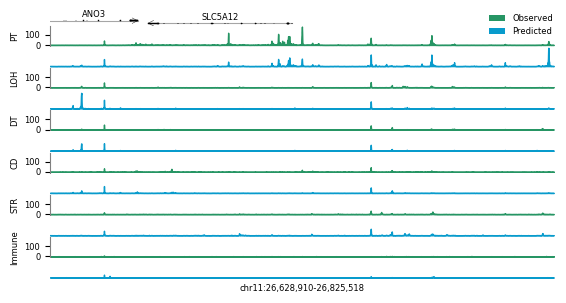

In [ ]:
# Create tracks dictionary for selected cells

interval = Interval('chr11', 26628910)

# Define cell IDs to plot
cell_ids = [8,9,7,3,1,0]

tracks_dict = {}
for cell_id in cell_ids:
    tracks_dict[cell_id] = {
        'target': targ[:, cell_id].numpy().squeeze(),
        'prediction': pred[:, cell_id].numpy().squeeze(),     
    }


colors = {'target': '#269564', 'prediction': '#089BCC'}

# Single function call to plot all cells
plot_tracks_with_genes(tracks_dict, interval, 'enformer', cell_ids, 
                       colors=colors, show_genes=True, bin_size=128,
                       add_center_line=False, gene_filter=None);

In [ ]:
data_dir = "./arather/ubiquitous/kidzoi/"
pred_path = "./arather/ubiquitous/kidzoi/all_ubiquitous_predictions.pt"
cells = ['Immune', 'stromal', 'Podocyte', 'CD', 'PE', 'Tcell', 'END', 'DT', 'PT', 'LOH']

corrs_df = compute_ubiquitous_correlations(
    data_dir=data_dir,
    predictions_path=pred_path,
    cells=cells,
    n_cell_ids=10,
    pred_slice=(4, 12)
)
corrs_df.columns = cells
corrs_df.index = cells

Immune - cell_0: Pearson r = 0.837
Immune - cell_1: Pearson r = 0.533
Immune - cell_2: Pearson r = 0.480
Immune - cell_3: Pearson r = 0.532
Immune - cell_4: Pearson r = 0.472
Immune - cell_5: Pearson r = 0.723
Immune - cell_6: Pearson r = 0.594
Immune - cell_7: Pearson r = 0.520
Immune - cell_8: Pearson r = 0.499
Immune - cell_9: Pearson r = 0.495
stromal - cell_0: Pearson r = 0.500
stromal - cell_1: Pearson r = 0.782
stromal - cell_2: Pearson r = 0.545
stromal - cell_3: Pearson r = 0.424
stromal - cell_4: Pearson r = 0.531
stromal - cell_5: Pearson r = 0.446
stromal - cell_6: Pearson r = 0.600
stromal - cell_7: Pearson r = 0.443
stromal - cell_8: Pearson r = 0.415
stromal - cell_9: Pearson r = 0.440
Podocyte - cell_0: Pearson r = 0.431
Podocyte - cell_1: Pearson r = 0.505
Podocyte - cell_2: Pearson r = 0.665
Podocyte - cell_3: Pearson r = 0.479
Podocyte - cell_4: Pearson r = 0.544
Podocyte - cell_5: Pearson r = 0.441
Podocyte - cell_6: Pearson r = 0.459
Podocyte - cell_7: Pearson r = 

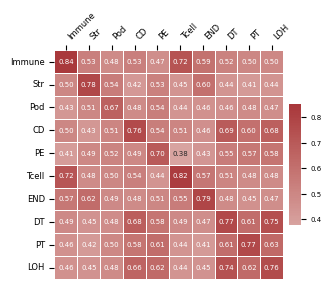

In [4]:
plot_correlation_heatmap(
    corrs_df,
    output_file="./fig2_ubiquitous.pdf"
)

In [ ]:
#model_name='borzoi_n_16k_n'

pred_dir = f"..//kidzoi/cell_specific/"
data_dir = f"../Kidzoi/cell_specific_bed/"

cells_bed = ['Immune', 'stromal', 'Podocyte', 'CD', 'PE', 'Tcell', 'END', 'DT', 'PT', 'LOH']
cells_pred = [
    'Immune_predictions',
    'stromal_predictions',
    'podocyte_predictions',
    'CollectingDuctIC_predictions',
    'ParietalEpithelial_predictions',
    'tcell_predictions',
    'Endothelial_predictions',
    'dt_predictions',
    'pt_predictions',
    'loh_predictions'
]

corrs_df = compute_cell_specific_correlations(
    target_dir = data_dir ,
    pred_dir= pred_dir,
    cells_bed=cells_bed, 
    cells_pred=cells_pred,
    n_cell_ids=10,
    pred_slice=(4, 12),
    model='borzoi'
    
)

Immune | cell_0: r = 0.677
Immune | cell_1: r = 0.216
Immune | cell_2: r = 0.048
Immune | cell_3: r = 0.148
Immune | cell_4: r = 0.175
Immune | cell_5: r = 0.225
Immune | cell_6: r = 0.222
Immune | cell_7: r = 0.171
Immune | cell_8: r = 0.140
Immune | cell_9: r = 0.140
stromal | cell_0: r = 0.165
stromal | cell_1: r = 0.529
stromal | cell_2: r = 0.014
stromal | cell_3: r = 0.103
stromal | cell_4: r = 0.097
stromal | cell_5: r = 0.131
stromal | cell_6: r = 0.206
stromal | cell_7: r = 0.087
stromal | cell_8: r = 0.082
stromal | cell_9: r = 0.071
Podocyte | cell_0: r = 0.017
Podocyte | cell_1: r = 0.084
Podocyte | cell_2: r = 0.508
Podocyte | cell_3: r = 0.056
Podocyte | cell_4: r = 0.204
Podocyte | cell_5: r = 0.013
Podocyte | cell_6: r = -0.017
Podocyte | cell_7: r = 0.035
Podocyte | cell_8: r = 0.002
Podocyte | cell_9: r = 0.057
CD | cell_0: r = 0.111
CD | cell_1: r = 0.077
CD | cell_2: r = -0.019
CD | cell_3: r = 0.624
CD | cell_4: r = 0.000
CD | cell_5: r = 0.125
CD | cell_6: r = 0.1

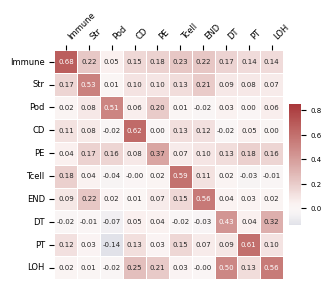

In [14]:
plot_correlation_heatmap(
    corrs_df,
    output_file="./fig2_cell_specific.pdf"
)